# Descriptive Analysis

The goal of this notebook is to understand the structure of the final merged life expectancy panel before performing statistical tests or predictive modeling. This notebook answers:

- How life expectancy is distributed globally
- How it changes over time
- Whether regions follow similar or different trajectories
- Whether the panel is well-formed and balanced
- Whether growth patterns suggest convergence between countries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

### Loading processed dataset

In [2]:
panel = pd.read_csv("../data/processed/main_dataset.csv")
panel.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,sanitation,injuries,communicable,noncommunicable_disease,life_expectancy_final
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,100,...,21.5,5949.999809,10.105348,3.25580,11.127,NaN,3673696.62,6528888.62,6988545.28,64.1885
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,100,...,20.7,4880.000114,9.528871,3.69522,11.142,NaN,3267937.78,6649335.87,6900348.40,61.4330
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,100,...,20.7,5989.999771,8.805941,3.45446,11.193,NaN,2807904.86,6813189.19,6799914.37,61.2125
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,100,...,21.1,8079.999924,7.897176,3.32000,11.341,NaN,2715550.23,7036448.02,6640268.93,60.7770
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,100,...,20.2,8930.000305,8.561907,3.46201,11.054,NaN,2540038.63,7181018.86,6539124.12,60.3765


In [3]:
panel.shape

(2265, 36)

In [4]:
panel.columns.tolist()

['country',
 'year',
 'status',
 'life_expectancy',
 'adult_mortality',
 'infant_deaths',
 'alcohol',
 'percentage_expenditure',
 'hepatitis_b',
 'measles',
 'bmi',
 'under_five_deaths',
 'polio',
 'total_expenditure',
 'diphtheria',
 'hiv_aids',
 'gdp',
 'population',
 'thinness_1_19_years',
 'thinness_5_9_years',
 'income_composition_of_resources',
 'schooling',
 'country_code',
 'region',
 'income_group',
 'life_expectancy_wb',
 'undernourishment',
 'co2',
 'health_expenditure_percent',
 'education_expenditure_percent',
 'unemployment',
 'sanitation',
 'injuries',
 'communicable',
 'noncommunicable_disease',
 'life_expectancy_final']

In [5]:
duplicates = panel.duplicated(subset=["country","year"]).sum()
duplicates


np.int64(0)

In [6]:
panel["year"].min(), panel["year"].max()

(np.int64(2001), np.int64(2015))

In [7]:
panel["country"].nunique()

151

## Observations by year

In [8]:
panel.groupby("year").size()

year
2001    151
2002    151
2003    151
2004    151
2005    151
2006    151
2007    151
2008    151
2009    151
2010    151
2011    151
2012    151
2013    151
2014    151
2015    151
dtype: int64

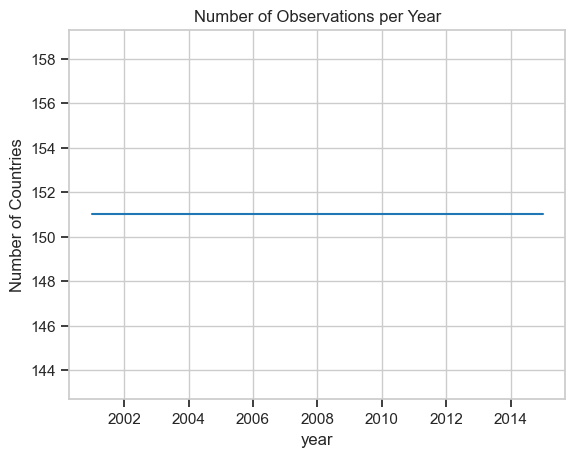

In [9]:
panel.groupby("year").size().plot()
plt.title("Number of Observations per Year")
plt.ylabel("Number of Countries")
plt.show()

### Basic descriptive statistics

In [10]:
panel["life_expectancy_final"].describe()

count    2265.000000
mean       69.243516
std         9.575684
min        40.684500
25%        62.840000
50%        72.091500
75%        75.846000
max        85.143902
Name: life_expectancy_final, dtype: float64

Skewness & Kurtois

In [12]:
panel["life_expectancy_final"].skew()

np.float64(-0.6659183337918904)

In [13]:
panel["life_expectancy_final"].kurtosis()

np.float64(-0.389918945741202)

The descriptive statistics of the merged panel indicate that global life expectancy is centered around 69.24 years, with a standard deviation of approximately 9.58 years, showing substantial variation across countries. The minimum observed value is 40.68 years, while the maximum reaches 85.14 years, confirming the presence of a wide development gap between the lowest- and highest-performing countries. The median life expectancy (72.09 years) is higher than the mean, which is consistent with the observed negative skewness (-0.67). This implies that a relatively small number of low-life-expectancy countries pull the global average downward, while most countries cluster in the higher range. The kurtosis value (-0.39) indicates a slightly flatter distribution than a normal distribution, meaning extreme outliers are limited and values are more evenly spread. Overall, the distribution suggests that while most countries have achieved moderately high life expectancy, a persistent lower tail remains, reflecting structural health and development inequalities across nations.

### Global Distribution (Histogram + KDE)

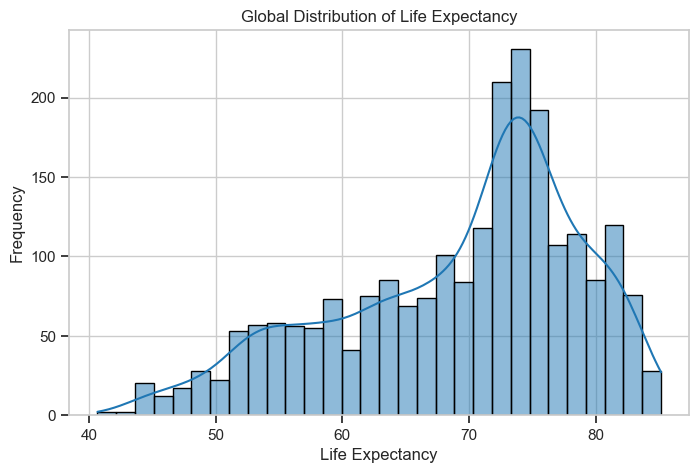

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(panel["life_expectancy_final"], bins=30, kde=True)
plt.title("Global Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

## Missingness

In [15]:
missing_table = panel.isna().mean().sort_values(ascending=False)
missing_table

sanitation                         0.352318
hepatitis_b                        0.178808
undernourishment                   0.145695
population                         0.094481
total_expenditure                  0.077704
alcohol                            0.071082
health_expenditure_percent         0.020751
bmi                                0.013245
thinness_5_9_years                 0.013245
thinness_1_19_years                0.013245
gdp                                0.008830
polio                              0.006623
diphtheria                         0.006623
income_composition_of_resources    0.006623
schooling                          0.006623
education_expenditure_percent      0.000000
income_group                       0.000000
unemployment                       0.000000
co2                                0.000000
injuries                           0.000000
communicable                       0.000000
noncommunicable_disease            0.000000
life_expectancy_wb              

## Global trend over time

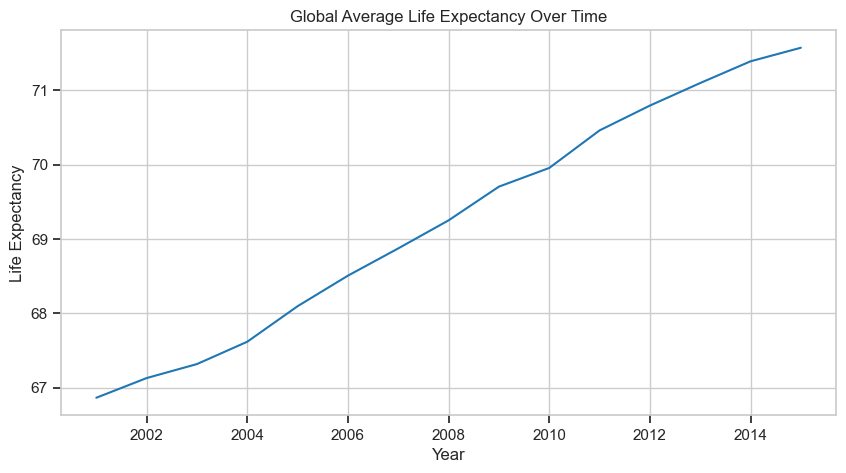

In [17]:
yearly_mean = panel.groupby("year")["life_expectancy_final"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_mean.index, yearly_mean.values)
plt.title("Global Average Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

### Smoothed rolling average

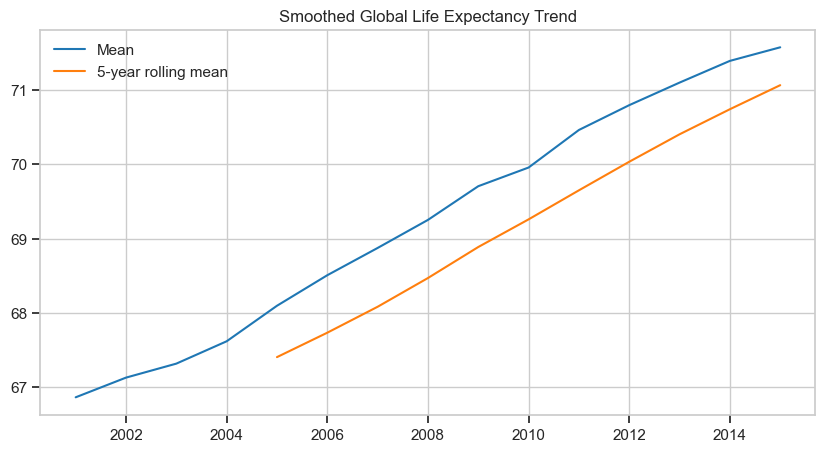

In [18]:
rolling = yearly_mean.rolling(5).mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_mean.index, yearly_mean, label="Mean")
plt.plot(rolling.index, rolling, label="5-year rolling mean")
plt.legend()
plt.title("Smoothed Global Life Expectancy Trend")
plt.show()


### Mean vs Median

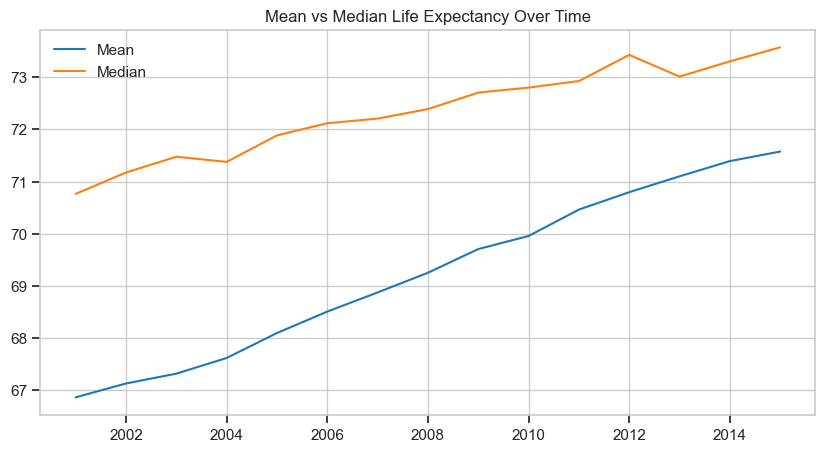

In [19]:
yearly_median = panel.groupby("year")["life_expectancy_final"].median()

plt.figure(figsize=(10,5))
plt.plot(yearly_mean.index, yearly_mean, label="Mean")
plt.plot(yearly_median.index, yearly_median, label="Median")
plt.legend()
plt.title("Mean vs Median Life Expectancy Over Time")
plt.show()

### Variability over time

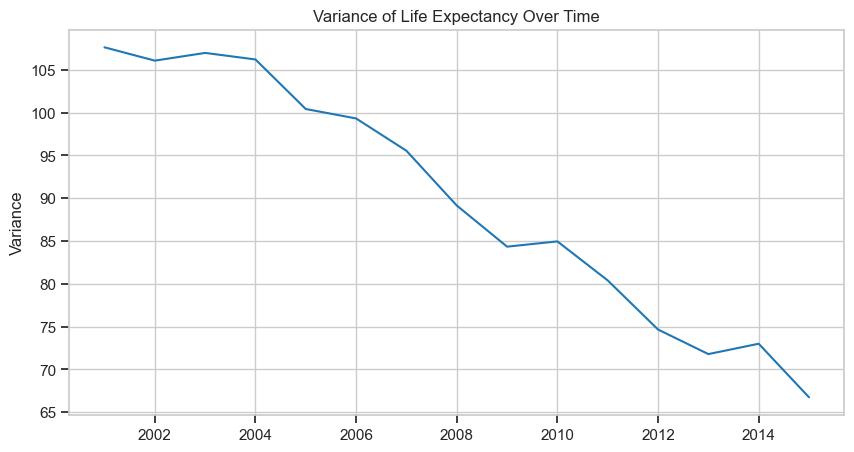

In [20]:
yearly_var = panel.groupby("year")["life_expectancy_final"].var()

plt.figure(figsize=(10,5))
plt.plot(yearly_var.index, yearly_var)
plt.title("Variance of Life Expectancy Over Time")
plt.ylabel("Variance")
plt.show()


## Regional Trends

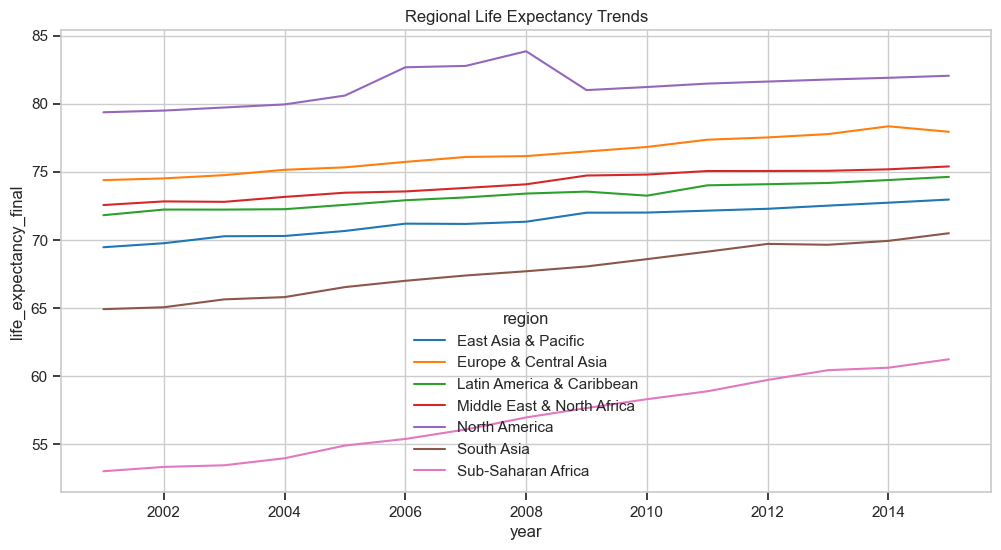

In [21]:
regional = panel.groupby(["year","region"])["life_expectancy_final"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=regional, x="year", y="life_expectancy_final", hue="region")
plt.title("Regional Life Expectancy Trends")
plt.show()

### Boxplots by region

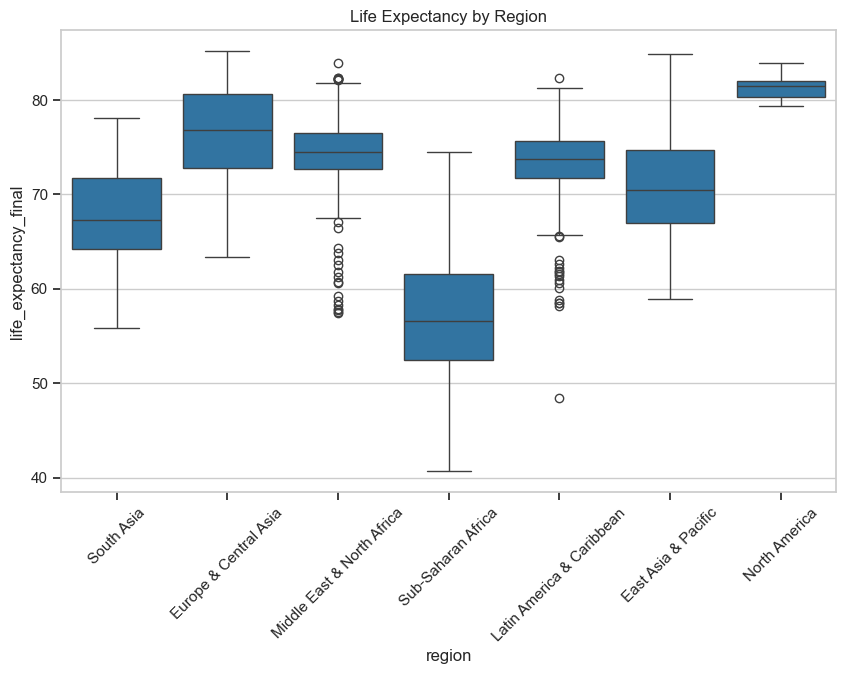

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=panel, x="region", y="life_expectancy_final")
plt.xticks(rotation=45)
plt.title("Life Expectancy by Region")
plt.show()

### Country Ranking

In [23]:
country_avg = panel.groupby("country")["life_expectancy_final"].mean().sort_values()

lowest = country_avg.head(10)
highest = country_avg.tail(10)

lowest, highest

(country
 Sierra Leone                46.887467
 Lesotho                     47.105833
 Central African Republic    47.653933
 Zimbabwe                    49.866533
 Chad                        50.337567
 Nigeria                     50.723967
 Angola                      51.254900
 Malawi                      51.557567
 Mozambique                  52.891000
 Somalia                     53.306033
 Name: life_expectancy_final, dtype: float64,
 country
 Canada         81.297561
 Norway         81.309106
 Australia      81.613333
 France         81.737398
 Spain          81.753740
 Sweden         81.898455
 Italy          81.937642
 Iceland        82.153089
 Switzerland    82.160894
 Japan          82.592919
 Name: life_expectancy_final, dtype: float64)

### Example Country Trajectories

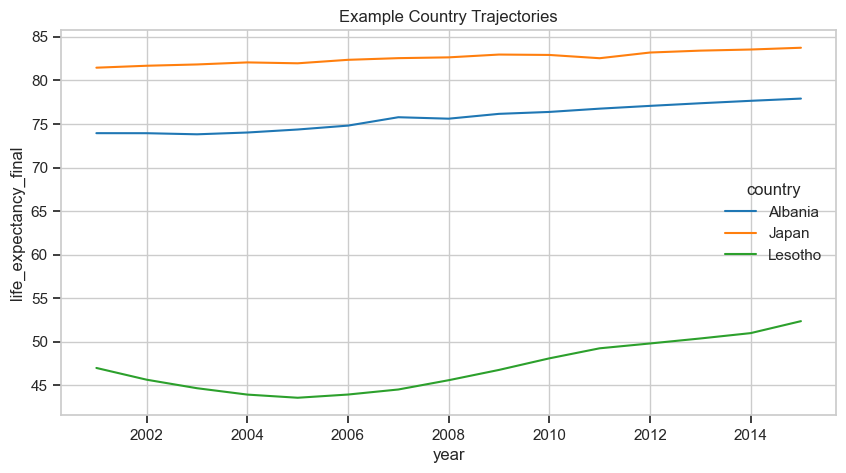

In [24]:
countries = ["Japan","Albania","Lesotho"]

subset = panel[panel["country"].isin(countries)]

plt.figure(figsize=(10,5))
sns.lineplot(data=subset, x="year", y="life_expectancy_final", hue="country")
plt.title("Example Country Trajectories")
plt.show()
